In [3]:
%pip install matplotlib seaborn

     ---------------------------------------- 9.3/9.3 MB 5.4 MB/s eta 0:00:00
     -------------------------------------- 294.9/294.9 kB 6.1 MB/s eta 0:00:00
     -------------------------------------- 225.2/225.2 kB 4.6 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 2.4/2.4 MB 7.5 MB/s eta 0:00:00
     ---------------------------------------- 73.5/73.5 kB 4.2 MB/s eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 4.5 MB/s eta 0:00:00
     -------------------------------------- 122.8/122.8 kB 7.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

# Load the dataset with specified encoding
data = pd.read_csv(
    'SampleSuperstore.csv',
    encoding='ISO-8859-1'  # Specify encoding to handle non-UTF-8 characters
)

In [6]:

# Convert date columns to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

# Extract year and month for analysis
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month

# Grouping and aggregating for insights
sales_by_category = data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
profit_by_category = data.groupby('Category')['Profit'].sum().sort_values(ascending=False)

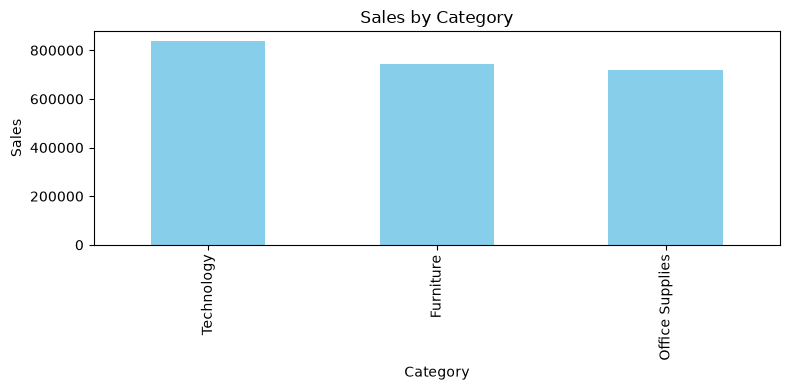

In [7]:
# Adjusted Visualization Sizes for 14-inch MacBook Pro Screen
plt.figure(figsize=(8, 4))  # Adjusted size
sales_by_category.plot(kind='bar', color='skyblue', title='Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.tight_layout()  # Ensures no clipping
plt.show()


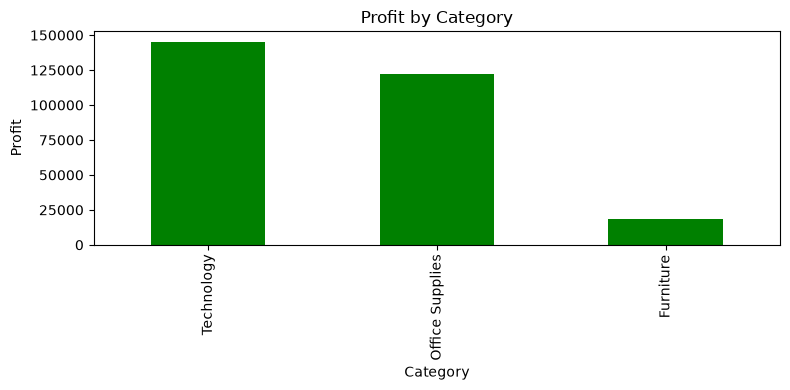

In [8]:
plt.figure(figsize=(8, 4))  # Adjusted size
profit_by_category.plot(kind='bar', color='green', title='Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

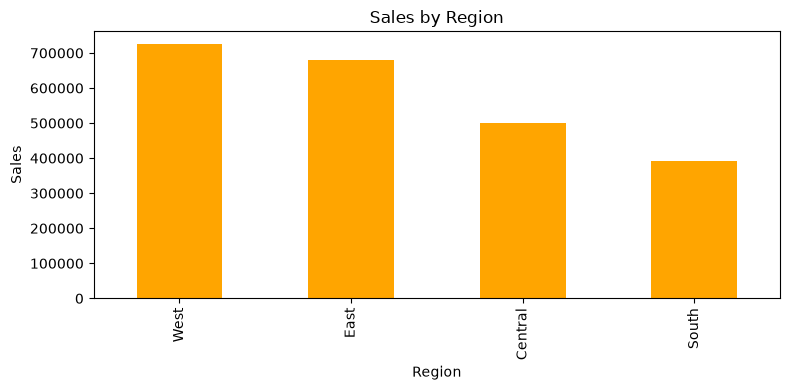

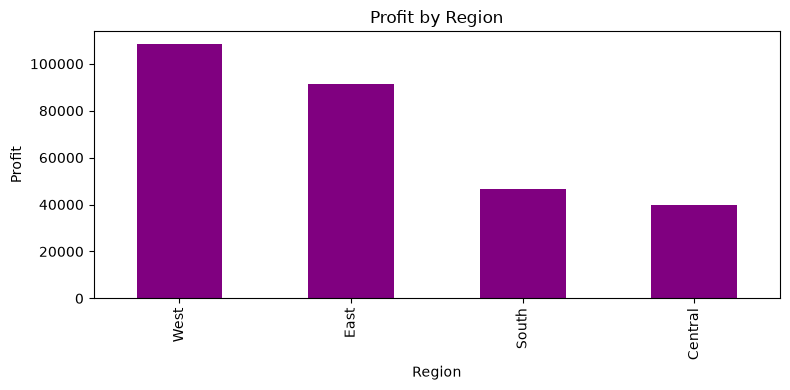

In [9]:
# Regional Analysis
sales_by_region = data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
profit_by_region = data.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))  # Adjusted size
sales_by_region.plot(kind='bar', color='orange', title='Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))  # Adjusted size
profit_by_region.plot(kind='bar', color='purple', title='Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


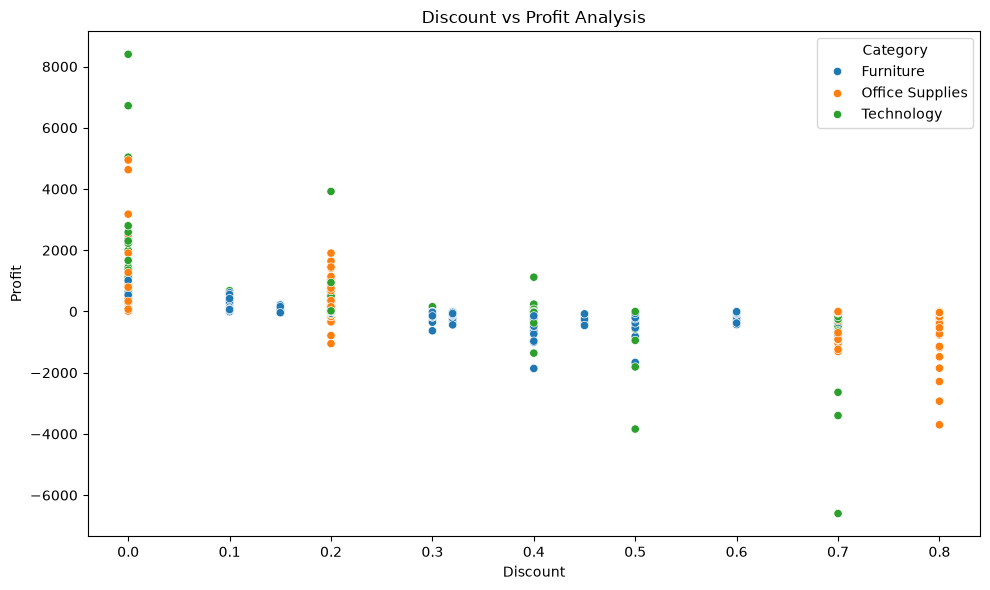

In [10]:
# Discount vs Profit Analysis
plt.figure(figsize=(10, 6))  # Slightly larger for scatterplots
sns.scatterplot(data=data, x='Discount', y='Profit', hue='Category')
plt.title('Discount vs Profit Analysis')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.legend(title='Category', loc='upper right')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

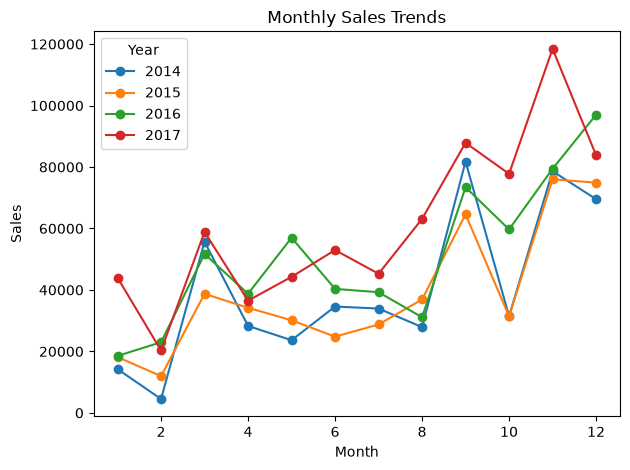

In [11]:
# Monthly Trends
monthly_sales = data.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
monthly_sales_pivot = monthly_sales.pivot(index='Month', columns='Year', values='Sales')

plt.figure(figsize=(10, 5))  # Adjusted size
monthly_sales_pivot.plot(kind='line', marker='o', title='Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend(title='Year', loc='upper left')
plt.tight_layout()
plt.show()


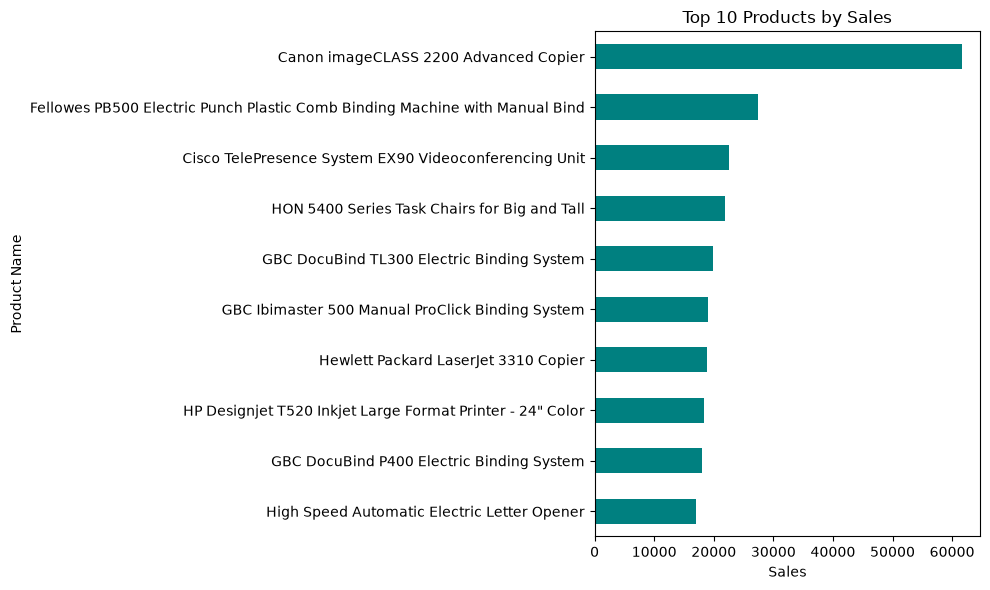

In [12]:
# Top Products by Sales
top_products = data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))  # Adjusted size
top_products.plot(kind='barh', color='teal', title='Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()  # Inverts the order for better readability
plt.tight_layout()
plt.show()
